# Imports and paths

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style",
)

PROJECT_ROOT = Path("..").resolve()

DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "monitoring_2026-05-21_2026-06-19"
)

print("Dataset path:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Dataset path: C:\Users\smsad\OneDrive\Desktop\greenmind-ai\data\raw\monitoring_2026-05-21_2026-06-19
Exists: True


# Find all air-quality files

In [2]:
air_files = sorted(
    DATASET_ROOT.glob("DEB-KER*/**/*Levego*.xlsx")
)

print("Air-quality files found:", len(air_files))

for file in air_files:
    print(file.relative_to(DATASET_ROOT))

Air-quality files found: 16
DEB-KER01\DEB-KER01_Levego.xlsx
DEB-KER02\DEB-KER02_Levego.xlsx
DEB-KER03\DEB-KER03_Levego.xlsx
DEB-KER04\DEB-KER04_Levego.xlsx
DEB-KER05\DEB-KER05_Levego.xlsx
DEB-KER06\DEB-KER06_Levego.xlsx
DEB-KER07\DEB-KER07_Levego.xlsx
DEB-KER08\DEB-KER08_Levego.xlsx
DEB-KER09\DEB-KER09_Levego.xlsx
DEB-KER10\DEB-KER10_Levego.xlsx
DEB-KER11\DEB-KER11_Levego.xlsx
DEB-KER12\DEB-KER12_Levego.xlsx
DEB-KER13\DEB-KER13_Levego.xlsx
DEB-KER14\DEB-KER14_Levego.xlsx
DEB-KER15\DEB-KER15_Levego.xlsx
DEB-KER18\DEB-KER18_Levego.xlsx


# Load and merge the files

In [3]:
dataframes = []

for file in air_files:
    station_data = pd.read_excel(file)

    station_data["source_file"] = file.stem
    station_data["station_code"] = file.parent.name

    dataframes.append(station_data)

raw_data = pd.concat(
    dataframes,
    ignore_index=True,
)

print("Dataset shape:", raw_data.shape)
raw_data.head()

Dataset shape: (117758, 7)


,timestamp,Location,Mérőeszköz,érték,mértékegység,source_file,station_code
0,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO,415.1,µg/m3,DEB-KER01_Levego,DEB-KER01
1,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO2,788.6,µg/m3,DEB-KER01_Levego,DEB-KER01
2,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Humidity,56.6,percent,DEB-KER01_Levego,DEB-KER01
3,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",NO2,20.7,µg/m3,DEB-KER01_Levego,DEB-KER01
4,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",O3,107.6,µg/m3,DEB-KER01_Levego,DEB-KER01


# Inspect columns and data types

In [4]:
display(raw_data.head(10))

print("\nColumns:")
print(raw_data.columns.tolist())

print("\nData types:")
print(raw_data.dtypes)

print("\nUnique stations:")
print(raw_data["station_code"].nunique())

print("\nUnique measurement types:")
print(raw_data["Mérőeszköz"].nunique())

,timestamp,Location,Mérőeszköz,érték,mértékegység,source_file,station_code
0,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO,415.1,µg/m3,DEB-KER01_Levego,DEB-KER01
1,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO2,788.6,µg/m3,DEB-KER01_Levego,DEB-KER01
2,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Humidity,56.6,percent,DEB-KER01_Levego,DEB-KER01
3,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",NO2,20.7,µg/m3,DEB-KER01_Levego,DEB-KER01
4,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",O3,107.6,µg/m3,DEB-KER01_Levego,DEB-KER01
5,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",PM10,11.6,µg/m3,DEB-KER01_Levego,DEB-KER01
6,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",PM2.5,6.6,µg/m3,DEB-KER01_Levego,DEB-KER01
7,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Pressure,1003.0,mbar,DEB-KER01_Levego,DEB-KER01
8,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Wind_Direction,286.6,degrees,DEB-KER01_Levego,DEB-KER01
9,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Wind_Speed,10.8,km/h,DEB-KER01_Levego,DEB-KER01



Columns:
['timestamp', 'Location', 'Mérőeszköz', 'érték', 'mértékegység', 'source_file', 'station_code']

Data types:
timestamp           str
Location            str
Mérőeszköz          str
érték           float64
mértékegység        str
source_file         str
station_code        str
dtype: object

Unique stations:
16

Unique measurement types:
13


# Rename columns

In [5]:
data = raw_data.rename(
    columns={
        "Location": "location",
        "Mérőeszköz": "measurement_type",
        "érték": "value",
        "mértékegység": "unit",
    }
).copy()

data.head()

,timestamp,location,measurement_type,value,unit,source_file,station_code
0,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO,415.1,µg/m3,DEB-KER01_Levego,DEB-KER01
1,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO2,788.6,µg/m3,DEB-KER01_Levego,DEB-KER01
2,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Humidity,56.6,percent,DEB-KER01_Levego,DEB-KER01
3,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",NO2,20.7,µg/m3,DEB-KER01_Levego,DEB-KER01
4,2026-05-21-02-00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",O3,107.6,µg/m3,DEB-KER01_Levego,DEB-KER01


# Parse timestamps and numeric values

In [6]:
data["timestamp"] = pd.to_datetime(
    data["timestamp"],
    format="%Y-%m-%d-%H-%M",
    errors="coerce",
)

data["value"] = pd.to_numeric(
    data["value"],
    errors="coerce",
)

print("Missing timestamps:", data["timestamp"].isna().sum())
print("Missing numeric values:", data["value"].isna().sum())

Missing timestamps: 0
Missing numeric values: 0


# Basic data-quality report

In [7]:
duplicate_mask = data.duplicated(
    subset=[
        "timestamp",
        "location",
        "measurement_type",
        "value",
    ],
    keep="first",
)

quality_report = {
    "original_rows": len(data),
    "duplicate_rows": int(duplicate_mask.sum()),
    "missing_timestamps": int(data["timestamp"].isna().sum()),
    "missing_values": int(data["value"].isna().sum()),
    "stations": int(data["station_code"].nunique()),
    "measurement_types": int(
        data["measurement_type"].nunique()
    ),
}

pd.Series(quality_report, name="value")

original_rows         117758
duplicate_rows             0
missing_timestamps         0
missing_values             0
stations                  16
measurement_types         13
Name: value, dtype: int64

# Inspect measurement names and units

In [8]:
measurement_summary = (
    data.groupby(["measurement_type", "unit"])
    .agg(
        row_count=("value", "size"),
        missing_count=("value", lambda series: series.isna().sum()),
        minimum=("value", "min"),
        maximum=("value", "max"),
        average=("value", "mean"),
    )
    .reset_index()
    .sort_values("measurement_type")
)

measurement_summary

,measurement_type,unit,row_count,missing_count,minimum,maximum,average
0,CO,µg/m3,9731,0,17.5,1529.2,347.625403
1,CO2,µg/m3,10627,0,690.6,1634.5,770.860120
2,Humidity,percent,11023,0,21.9,87.5,52.849932
3,NO,µg/m3,3890,0,0.7,70.1,2.684602
4,NO2,µg/m3,10557,0,0.9,66.8,14.187118
5,NOx,µg/m3,3860,0,1.9,101.7,19.680881
6,O3,µg/m3,10998,0,12.0,586.2,116.876896
7,PM10,µg/m3,11022,0,0.5,4100.7,12.097686
8,PM2.5,µg/m3,11022,0,0.5,170.3,5.071639
9,Pressure,mbar,11023,0,989.0,1014.7,1002.039309


# Define validation ranges

In [9]:
VALID_RANGES = {
    "PM2.5": (0, 1000),
    "PM10": (0, 1500),
    "CO": (0, 100000),
    "CO2": (0, 10000),
    "NO": (0, 1000),
    "NO2": (0, 1000),
    "NOx": (0, 2000),
    "O3": (0, 1000),
    "TVOC": (0, 10000),
    "Humidity": (0, 100),
    "Pressure": (800, 1200),
    "Wind_Speed": (0, 100),
    "Wind_Direction": (0, 360),
}

# Detect invalid values

In [10]:
data["value_status"] = "observed"

invalid_count = 0

for measurement_type, (minimum, maximum) in VALID_RANGES.items():
    invalid_mask = (
        data["measurement_type"].eq(measurement_type)
        & data["value"].notna()
        & (
            (data["value"] < minimum)
            | (data["value"] > maximum)
        )
    )

    invalid_count += int(invalid_mask.sum())

    data.loc[invalid_mask, "value"] = pd.NA
    data.loc[invalid_mask, "value_status"] = "invalid"

data.loc[
    data["value"].isna()
    & data["value_status"].eq("observed"),
    "value_status",
] = "missing"

print("Invalid values converted to missing:", invalid_count)

data["value_status"].value_counts()

Invalid values converted to missing: 1


value_status
observed    117757
invalid          1
Name: count, dtype: int64

# Remove duplicates and round values

In [11]:
cleaned_data = data.loc[~duplicate_mask].copy()

cleaned_data["value"] = cleaned_data["value"].round(2)

cleaned_data = cleaned_data[
    cleaned_data["timestamp"].notna()
    & cleaned_data["location"].notna()
    & cleaned_data["measurement_type"].notna()
].reset_index(drop=True)

print("Cleaned dataset shape:", cleaned_data.shape)
cleaned_data.head()

Cleaned dataset shape: (117758, 8)


,timestamp,location,measurement_type,value,unit,source_file,station_code,value_status
0,2026-05-21 02:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO,415.1,µg/m3,DEB-KER01_Levego,DEB-KER01,observed
1,2026-05-21 02:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",CO2,788.6,µg/m3,DEB-KER01_Levego,DEB-KER01,observed
2,2026-05-21 02:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",Humidity,56.6,percent,DEB-KER01_Levego,DEB-KER01,observed
3,2026-05-21 02:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",NO2,20.7,µg/m3,DEB-KER01_Levego,DEB-KER01,observed
4,2026-05-21 02:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",O3,107.6,µg/m3,DEB-KER01_Levego,DEB-KER01,observed


# Final cleaning report

In [12]:
final_report = {
    "original_rows": len(raw_data),
    "duplicates_removed": int(duplicate_mask.sum()),
    "invalid_values": invalid_count,
    "missing_after_cleaning": int(
        cleaned_data["value"].isna().sum()
    ),
    "final_rows": len(cleaned_data),
    "stations": int(cleaned_data["station_code"].nunique()),
    "measurement_types": int(
        cleaned_data["measurement_type"].nunique()
    ),
}

pd.Series(final_report, name="value")

original_rows             117758
duplicates_removed             0
invalid_values                 1
missing_after_cleaning         1
final_rows                117758
stations                      16
measurement_types             13
Name: value, dtype: int64

# Convert to wide format

In [13]:
COLUMN_NAMES = {
    "PM2.5": "pm25",
    "PM10": "pm10",
    "CO": "co",
    "CO2": "co2",
    "NO": "no",
    "NO2": "no2",
    "NOx": "nox",
    "O3": "o3",
    "TVOC": "tvoc",
    "Humidity": "humidity",
    "Pressure": "pressure",
    "Wind_Speed": "wind_speed",
    "Wind_Direction": "wind_direction",
}

wide_source = cleaned_data.copy()

wide_source["measurement_type"] = (
    wide_source["measurement_type"].replace(COLUMN_NAMES)
)

wide_data = (
    wide_source.pivot_table(
        index=[
            "timestamp",
            "location",
            "station_code",
            "source_file",
        ],
        columns="measurement_type",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
    .sort_values(["station_code", "timestamp"])
    .reset_index(drop=True)
)

wide_data.columns.name = None

print("Wide dataset shape:", wide_data.shape)
print(wide_data.columns.tolist())

wide_data.head()

Wide dataset shape: (11024, 17)
['timestamp', 'location', 'station_code', 'source_file', 'co', 'co2', 'humidity', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm25', 'pressure', 'tvoc', 'wind_direction', 'wind_speed']


,timestamp,location,station_code,source_file,co,co2,humidity,no,no2,nox,o3,pm10,pm25,pressure,tvoc,wind_direction,wind_speed
0,2026-05-21 02:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",DEB-KER01,DEB-KER01_Levego,415.1,788.6,56.6,NaN,20.7,NaN,107.6,11.6,6.6,1003.0,NaN,286.6,10.8
1,2026-05-21 03:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",DEB-KER01,DEB-KER01_Levego,414.5,793.5,59.7,NaN,21.0,NaN,102.9,8.0,6.0,1002.5,NaN,292.6,10.4
2,2026-05-21 04:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",DEB-KER01,DEB-KER01_Levego,419.2,804.9,62.8,NaN,18.8,NaN,94.5,11.1,6.8,1002.9,NaN,308.4,8.7
3,2026-05-21 05:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",DEB-KER01,DEB-KER01_Levego,426.4,806.7,65.9,0.7,19.1,18.4,89.5,11.4,7.7,1003.0,NaN,308.9,9.6
4,2026-05-21 06:00:00,"ÉNYGÖ, BMW körút (47.577175, 21.502204)",DEB-KER01,DEB-KER01_Levego,442.7,802.1,68.1,0.7,18.1,17.6,91.4,12.9,8.6,1003.4,NaN,303.4,12.4


# Missing values in wide format

In [14]:
missing_summary = (
    wide_data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"]
    / len(wide_data)
    * 100
).round(2)

missing_summary

,missing_values,missing_percentage
tvoc,7653,69.42
nox,7164,64.99
no,7134,64.71
co,1293,11.73
wind_speed,707,6.41
wind_direction,707,6.41
no2,467,4.24
co2,397,3.60
o3,26,0.24
pm10,3,0.03


# PM2.5 trend by station

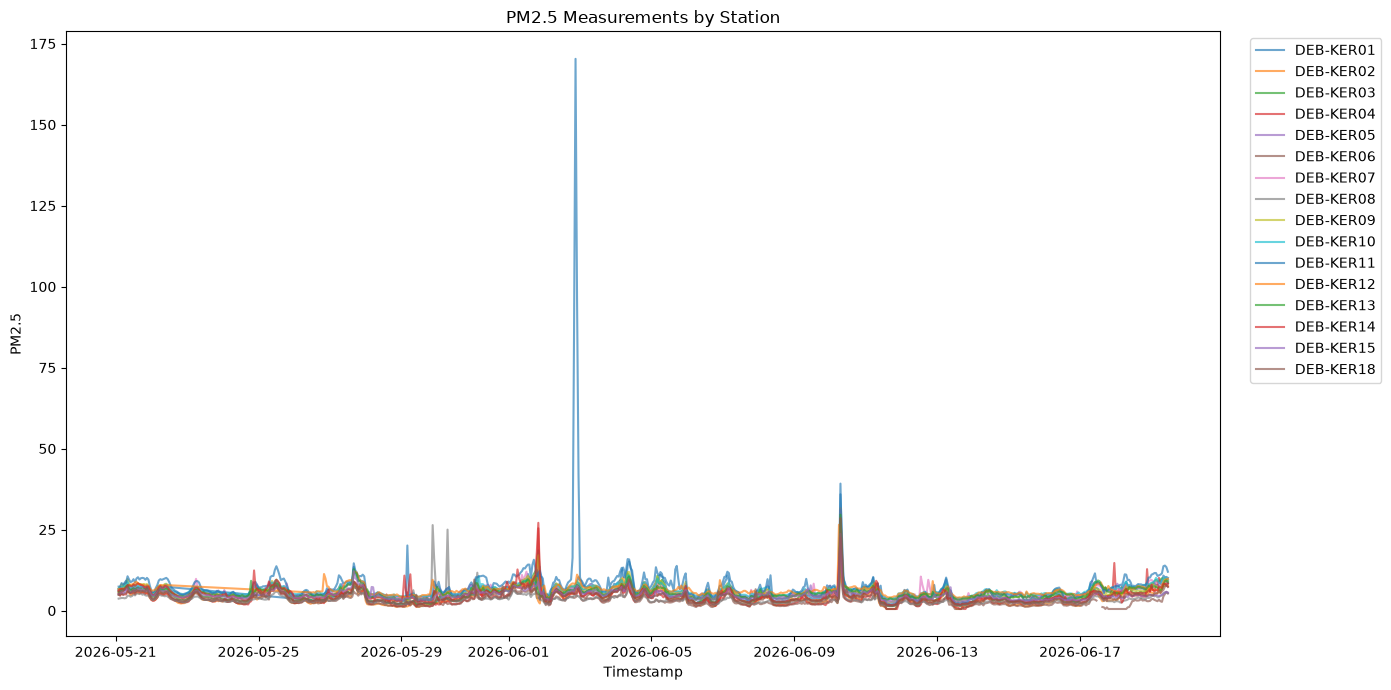

In [15]:
pm25_hourly = (
    wide_data.groupby(["timestamp", "station_code"])["pm25"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for station_code, station_data in pm25_hourly.groupby("station_code"):
    plt.plot(
        station_data["timestamp"],
        station_data["pm25"],
        label=station_code,
        alpha=0.65,
    )

plt.title("PM2.5 Measurements by Station")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

# Average pollution by station

In [16]:
station_averages = (
    wide_data.groupby("station_code")
    .agg(
        average_pm25=("pm25", "mean"),
        average_pm10=("pm10", "mean"),
        average_no2=("no2", "mean"),
        average_o3=("o3", "mean"),
        average_wind_speed=("wind_speed", "mean"),
    )
    .round(2)
    .sort_values("average_pm25", ascending=False)
)

station_averages

,average_pm25,average_pm10,average_no2,average_o3,average_wind_speed
station_code,,,,,
DEB-KER11,7.46,23.18,13.20,122.19,5.46
DEB-KER10,6.39,14.40,19.70,82.86,4.20
DEB-KER12,6.35,14.16,9.84,86.85,2.68
DEB-KER07,6.16,14.23,13.41,125.30,4.92
DEB-KER05,5.77,12.27,15.25,123.51,4.34
DEB-KER09,5.67,11.00,12.34,91.23,0.00
DEB-KER13,5.56,13.57,17.15,111.28,2.57
DEB-KER01,5.30,11.33,14.16,129.03,11.18
DEB-KER14,4.85,10.57,9.10,152.82,6.59


# Save cleaned outputs

In [17]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

cleaned_long_path = PROCESSED_DIR / "air_measurements_cleaned.csv"
cleaned_wide_path = PROCESSED_DIR / "air_measurements_wide.csv"

cleaned_data.to_csv(
    cleaned_long_path,
    index=False,
)

wide_data.to_csv(
    cleaned_wide_path,
    index=False,
)

print("Saved:")
print(cleaned_long_path)
print(cleaned_wide_path)

Saved:
C:\Users\smsad\OneDrive\Desktop\greenmind-ai\data\processed\air_measurements_cleaned.csv
C:\Users\smsad\OneDrive\Desktop\greenmind-ai\data\processed\air_measurements_wide.csv
